<a href="https://colab.research.google.com/github/AKSIbyte/Water-quality-Management-system-1.0/blob/main/Water%20Quality%20and%20Aquculture_Training_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Data IoTMLCQ.xlsx to Data IoTMLCQ.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel("Data IoTMLCQ.xlsx")  # use exact uploaded name
df.head()

,id,temperatura,oxigeno,ph,turbidez,hour,day,month,temperatura_scaled,oxigeno_scaled
0,49,1.001750,0.089269,0.937644,-0.008761,19,17,1,27.041814,7.968205
1,55,1.044218,0.621644,0.936319,-0.043164,19,24,1,27.330717,8.190253
2,88,0.981081,0.234554,0.997134,0.027833,20,25,1,26.901205,8.028802
3,106,0.990495,-0.715270,0.946473,0.017791,20,27,1,26.965247,7.632639
4,113,1.031420,-0.611011,0.906770,0.006865,20,5,1,27.243652,7.676124


Saving Data IoTMLCQ.xlsx to Data IoTMLCQ (3).xlsx
Original Columns: Index(['id', 'temperatura', 'oxigeno', 'ph', 'turbidez', 'hour', 'day',
       'month', 'temperatura_scaled', 'oxigeno_scaled'],
      dtype='object')
Fixed Columns: Index(['id', 'temperature', 'oxygen', 'ph', 'turbidity', 'hour', 'day',
       'month', 'temperatura_scaled', 'oxigeno_scaled'],
      dtype='object')


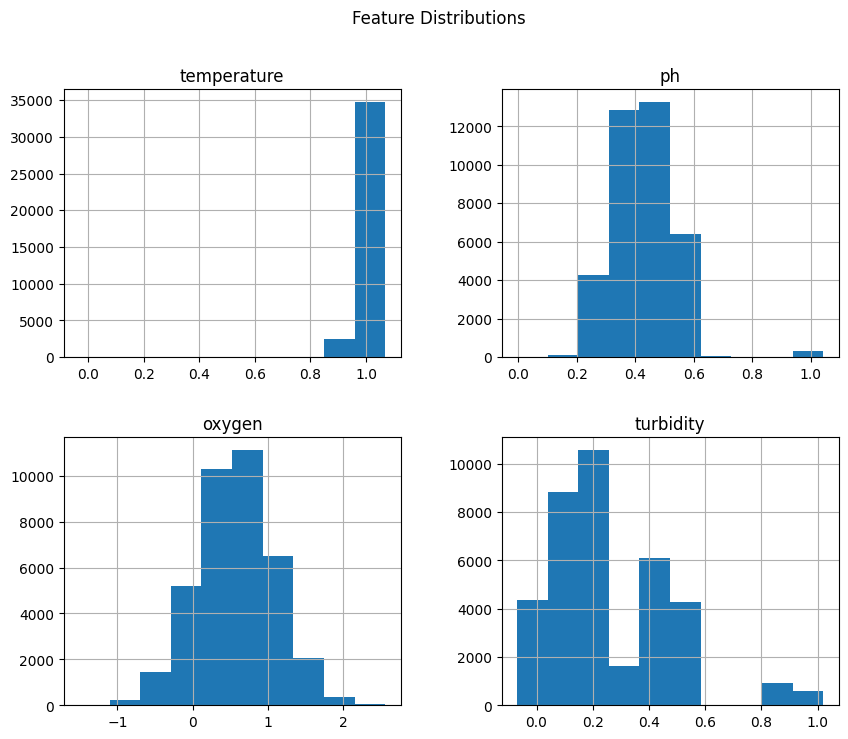

READY 


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()



df = pd.read_excel("Data IoTMLCQ.xlsx")
df.columns = df.columns.str.lower().str.strip()

print("Original Columns:", df.columns)
df = df.rename(columns={
    'temperatura': 'temperature',
    'oxigeno': 'oxygen',
    'turbidez': 'turbidity'
})

print("Fixed Columns:", df.columns)
df = df.dropna()
df[['temperature','ph','oxygen','turbidity']].hist(figsize=(10,8))
plt.suptitle("Feature Distributions")
plt.show()
X = df[['temperature', 'ph', 'oxygen']]
y = df['turbidity']

print("READY ")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, pred))

MSE: 0.027379899341117096


In [ ]:
def classify(row):
    if row['oxygen'] < 3 or row['ph'] < 6 or row['ph'] > 9:
        return 2
    elif row['oxygen'] < 5:
        return 1
    else:
        return 0

df['label'] = df.apply(classify, axis=1)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_cls = df[['temperature','ph','oxygen','turbidity']]
y_cls = df['label']

X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, test_size=0.2)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 1.0


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2330/2330 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 0.0076
Epoch 2/5
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 8.0171e-04
Epoch 3/5
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 7.7877e-04
Epoch 4/5
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 32s 6ms/step - loss: 7.5219e-04
Epoch 5/5
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 7.3912e-04
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


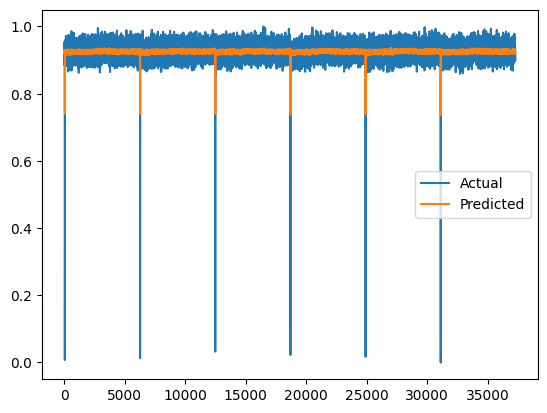

In [ ]:
from sklearn.preprocessing import MinMaxScaler

data = df[['temperature']].values

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

X_lstm, y_lstm = [], []

for i in range(10, len(data_scaled)):
    X_lstm.append(data_scaled[i-10:i])
    y_lstm.append(data_scaled[i])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(50, input_shape=(X_lstm.shape[1], 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.fit(X_lstm, y_lstm, epochs=5, batch_size=16)

pred = model.predict(X_lstm)

plt.plot(y_lstm, label="Actual")
plt.plot(pred, label="Predicted")
plt.legend()
plt.show()